<a href="https://colab.research.google.com/github/angeruzzi/home-credit-default-risk/blob/main/notebooks/06_lightgbm_challenger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — LightGBM Challenger

## Introdução

### 1. Contexto

Este notebook desenvolverá o modelo challenger de Application Score utilizando o algoritmo LightGBM.

Diferentemente da abordagem tradicional construída no notebook anterior, o LightGBM não depende da transformação das features por Binning e Weight of Evidence.

O algoritmo é baseado em conjuntos de árvores de decisão treinadas sequencialmente por gradient boosting e possui capacidade para representar:

- relações não lineares;
- interações entre features;
- diferentes pontos de corte;
- efeitos condicionais;
- missing values;
- variáveis categóricas.

O fluxo geral deste notebook será:

$$
\text{Dados consolidados}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{LightGBM}
\rightarrow
\text{Tuning}
\rightarrow
\text{PD}
\rightarrow
\text{Avaliação}
$$

O modelo será tratado como **challenger**, ou seja, uma alternativa ao modelo tradicional de Logistic Regression.

O objetivo não será simplesmente obter uma ROC-AUC superior. A comparação posterior também considerará:

- discriminação;
- calibração;
- estabilidade;
- complexidade;
- interpretabilidade;
- facilidade de governança;
- adequação ao contexto de risco de crédito.

O LightGBM utilizará as features consolidadas nos notebooks de preparação, sem restringir seu universo às variáveis selecionadas por IV no modelo tradicional.

Essa decisão é importante porque uma feature com baixa capacidade preditiva individual pode contribuir para o LightGBM por meio de relações não lineares ou interações com outras features.

### 2. Objetivos

Os principais objetivos deste notebook são:

1. carregar as mesmas amostras de train, validation e holdout test utilizadas no modelo tradicional;
2. definir o universo de features elegíveis para o challenger;
3. preparar features numéricas e categóricas para o LightGBM;
4. construir um baseline com parâmetros controlados;
5. avaliar o risco de overfitting;
6. realizar o tuning utilizando apenas train e validation;
7. selecionar o modelo challenger;
8. avaliar discriminação e calibração;
9. interpretar o modelo por feature importance e SHAP;
10. realizar a avaliação final no mesmo holdout test utilizado pela Logistic Regression;
11. persistir o modelo, as previsões, as métricas e os artefatos de interpretabilidade.

A separação entre as amostras será preservada:

- **train:** estimação do modelo;
- **validation:** seleção de parâmetros e controle de overfitting;
- **holdout test:** avaliação final após o encerramento das decisões de modelagem.

O holdout test não será utilizado para seleção de features, tuning de hiperparâmetros, definição do número de árvores ou escolha do modelo.

### 3. Papel do modelo challenger

O LightGBM será comparado ao modelo tradicional em condições equivalentes:

- mesma população;
- mesmo target;
- mesmas amostras;
- mesmo holdout;
- mesmas métricas principais.

O modelo challenger poderá apresentar maior capacidade discriminatória ao capturar relações não lineares e interações. Em contrapartida, sua interpretação é mais complexa e dependerá de ferramentas como SHAP.

A comparação final não pressupõe que o modelo com maior ROC-AUC será automaticamente escolhido como champion.

Uma eventual substituição deverá considerar se o ganho preditivo compensa:

- aumento de complexidade;
- maior dificuldade de explicação;
- risco de overfitting;
- custo de monitoramento;
- exigências de governança.

## Configuração do Ambiente

Esta seção prepara o ambiente de execução, identifica a raiz do projeto, instala as dependências registradas no `requirements.txt` e configura os diretórios utilizados para leitura e persistência dos dados e artefatos.

No Google Colab, o código será executado em `/content/home-credit-default-risk`, enquanto os dados e artefatos persistentes serão acessados no Google Drive.

In [4]:
# Inicialização do ambiente
import os
import sys
import subprocess
from pathlib import Path
import importlib

IN_COLAB = "google.colab" in sys.modules

REPOSITORY_URL = (
    "https://github.com/angeruzzi/home-credit-default-risk.git"
)

if IN_COLAB:
    PROJECT_ROOT = Path(
        "/content/home-credit-default-risk"
    )

    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPOSITORY_URL,
                str(PROJECT_ROOT),
            ],
            check=True,
        )

    else:
        git_status = subprocess.run(
            [
                "git",
                "-C",
                str(PROJECT_ROOT),
                "status",
                "--porcelain",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

        if git_status.stdout.strip():
            print(
                "O repositório possui alterações locais. "
                "O git pull automático não será executado."
            )
            print(git_status.stdout)

        else:
            subprocess.run(
                [
                    "git",
                    "-C",
                    str(PROJECT_ROOT),
                    "pull",
                    "--ff-only",
                    "origin",
                    "main",
                ],
                check=True,
            )

else:
    current_directory = Path.cwd().resolve()

    PROJECT_ROOT = (
        current_directory.parent
        if current_directory.name == "notebooks"
        else current_directory
    )

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /content/home-credit-default-risk


In [5]:
# Instalação das dependências
REQUIREMENTS_PATH = (
    PROJECT_ROOT / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {REQUIREMENTS_PATH}"
    )

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    check=True,
)

print("Dependências instaladas com sucesso.")

Dependências instaladas com sucesso.


In [6]:
# Configuração dos diretórios do projeto
import utils

importlib.reload(utils)

from utils import setup_project

paths = setup_project(
    use_google_drive_cache=True,
)

print(paths)

Mounted at /content/drive
Ambiente Colab: True
Modo de armazenamento: Google Drive
Raiz do projeto: /content/home-credit-default-risk
Dados: /content/drive/MyDrive/home-credit-default-risk/data
Artefatos: /content/drive/MyDrive/home-credit-default-risk/artifacts
Relatórios: /content/home-credit-default-risk/reports
ProjectPaths(project_root=PosixPath('/content/home-credit-default-risk'), data_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data'), data_raw=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/raw'), data_interim=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/interim'), data_processed=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/processed'), artifacts_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts'), models=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/models'), preprocessing=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/preprocessing'),

In [7]:
# Importação das bibliotecas
import json
import platform
import time
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import shap
import sklearn

from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    200,
)

pd.set_option(
    "display.max_rows",
    200,
)

pd.set_option(
    "display.float_format",
    "{:,.4f}".format,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

RANDOM_STATE = 42
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


### 4. Registro das versões

As versões das principais bibliotecas utilizadas serão registradas como metadata.

Esse registro facilita a reprodução do notebook e a investigação de diferenças provocadas por atualizações nas dependências, especialmente no LightGBM e no SHAP.

In [8]:
# Registro das versões
library_versions = pd.DataFrame(
    [
        {
            "componente": "Python",
            "versao": (
                platform.python_version()
            ),
        },
        {
            "componente": "NumPy",
            "versao": np.__version__,
        },
        {
            "componente": "Pandas",
            "versao": pd.__version__,
        },
        {
            "componente": "SciPy",
            "versao": scipy.__version__,
        },
        {
            "componente": "Scikit-learn",
            "versao": sklearn.__version__,
        },
        {
            "componente": "LightGBM",
            "versao": lgb.__version__,
        },
        {
            "componente": "SHAP",
            "versao": shap.__version__,
        },
        {
            "componente": "Joblib",
            "versao": joblib.__version__,
        },
    ]
)

display(library_versions)

,componente,versao
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,SciPy,1.16.3
4,Scikit-learn,1.6.1
5,LightGBM,4.6.0
6,SHAP,0.52.0
7,Joblib,1.6.0


In [9]:
# Persistência das versões
VERSIONS_PATH = (
    paths.metadata
    / "lightgbm_challenger_versions.csv"
)

library_versions.to_csv(
    VERSIONS_PATH,
    index=False,
)

print(
    f"Versões registradas em: "
    f"{VERSIONS_PATH}"
)

Versões registradas em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/lightgbm_challenger_versions.csv


## Carregamento das Amostras

O challenger utilizará exatamente as mesmas amostras empregadas no modelo tradicional:

- train;
- validation;
- holdout test.

Nenhuma nova divisão será realizada. A manutenção das mesmas observações em cada amostra é necessária para que a comparação entre os modelos seja pareada e metodologicamente válida.

In [10]:
# Definição dos arquivos de modelagem
TRAIN_PATH = (
    paths.data_processed
    / "modeling_train_full.parquet"
)

VALIDATION_PATH = (
    paths.data_processed
    / "modeling_validation_full.parquet"
)

HOLDOUT_TEST_PATH = (
    paths.data_processed
    / "modeling_holdout_test_full.parquet"
)

modeling_paths = {
    "train": TRAIN_PATH,
    "validation": VALIDATION_PATH,
    "holdout_test": HOLDOUT_TEST_PATH,
}

for sample_name, file_path in (
    modeling_paths.items()
):
    print(
        f"{sample_name}: "
        f"{file_path} | "
        f"existe={file_path.exists()}"
    )

train: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_train_full.parquet | existe=True
validation: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_validation_full.parquet | existe=True
holdout_test: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_holdout_test_full.parquet | existe=True


In [11]:
# Interrupção se houver arquivos ausentes
missing_modeling_files = [
    str(file_path)
    for file_path in modeling_paths.values()
    if not file_path.exists()
]

if missing_modeling_files:
    raise FileNotFoundError(
        "Os seguintes arquivos não foram encontrados:\n"
        + "\n".join(
            missing_modeling_files
        )
    )

print(
    "Todos os arquivos de modelagem "
    "foram encontrados."
)

Todos os arquivos de modelagem foram encontrados.


In [12]:
# Leitura das amostras
train_df = pd.read_parquet(
    TRAIN_PATH
)

validation_df = pd.read_parquet(
    VALIDATION_PATH
)

holdout_test_df = pd.read_parquet(
    HOLDOUT_TEST_PATH
)

print("Amostras carregadas com sucesso.")

Amostras carregadas com sucesso.


In [13]:
# Resumo das amostras
sample_summary = pd.DataFrame(
    [
        {
            "sample": "train",
            "rows": train_df.shape[0],
            "columns": train_df.shape[1],
            "events": int(
                train_df[
                    TARGET_COLUMN
                ].sum()
            ),
            "event_rate": (
                train_df[
                    TARGET_COLUMN
                ].mean()
            ),
        },
        {
            "sample": "validation",
            "rows": (
                validation_df.shape[0]
            ),
            "columns": (
                validation_df.shape[1]
            ),
            "events": int(
                validation_df[
                    TARGET_COLUMN
                ].sum()
            ),
            "event_rate": (
                validation_df[
                    TARGET_COLUMN
                ].mean()
            ),
        },
        {
            "sample": "holdout_test",
            "rows": (
                holdout_test_df.shape[0]
            ),
            "columns": (
                holdout_test_df.shape[1]
            ),
            "events": int(
                holdout_test_df[
                    TARGET_COLUMN
                ].sum()
            ),
            "event_rate": (
                holdout_test_df[
                    TARGET_COLUMN
                ].mean()
            ),
        },
    ]
)

display(sample_summary)

,sample,rows,columns,events,event_rate
0,train,215257,327,17377,0.0807
1,validation,46127,327,3724,0.0807
2,holdout_test,46127,327,3724,0.0807


In [14]:
# Validação da estrutura das amostras
sample_dataframes = {
    "train": train_df,
    "validation": validation_df,
    "holdout_test": holdout_test_df,
}

required_columns = {
    ID_COLUMN,
    TARGET_COLUMN,
}

reference_columns = set(
    train_df.columns
)

for sample_name, sample_df in (
    sample_dataframes.items()
):
    missing_required_columns = (
        required_columns
        - set(sample_df.columns)
    )

    if missing_required_columns:
        raise ValueError(
            f"{sample_name} não contém: "
            f"{sorted(missing_required_columns)}"
        )

    if sample_df[ID_COLUMN].isna().any():
        raise ValueError(
            f"{sample_name} contém IDs ausentes."
        )

    if sample_df[ID_COLUMN].duplicated().any():
        raise ValueError(
            f"{sample_name} contém IDs duplicados."
        )

    if sample_df[TARGET_COLUMN].isna().any():
        raise ValueError(
            f"{sample_name} contém target ausente."
        )

    if set(sample_df.columns) != reference_columns:
        raise ValueError(
            f"{sample_name} possui estrutura "
            "diferente do train."
        )

print(
    "Estrutura das três amostras validada."
)

Estrutura das três amostras validada.


In [15]:
# Validação da independência das amostras
train_ids = set(
    train_df[ID_COLUMN]
)

validation_ids = set(
    validation_df[ID_COLUMN]
)

holdout_test_ids = set(
    holdout_test_df[ID_COLUMN]
)

sample_intersections = {
    "train_validation": len(
        train_ids & validation_ids
    ),
    "train_holdout_test": len(
        train_ids & holdout_test_ids
    ),
    "validation_holdout_test": len(
        validation_ids & holdout_test_ids
    ),
}

display(
    pd.DataFrame(
        [
            {
                "comparison": comparison,
                "common_ids": common_ids,
            }
            for comparison, common_ids
            in sample_intersections.items()
        ]
    )
)

if any(sample_intersections.values()):
    raise ValueError(
        "Há clientes presentes em mais "
        "de uma amostra."
    )

print(
    "Não há sobreposição de clientes."
)

,comparison,common_ids
0,train_validation,0
1,train_holdout_test,0
2,validation_holdout_test,0


Não há sobreposição de clientes.


## Preparação das Features

### 1. Universo de features do challenger

O LightGBM utilizará todas as features tecnicamente elegíveis disponíveis na base consolidada.

Diferentemente da Logistic Regression, não será aplicado filtro por Information Value, pois o LightGBM pode aproveitar:

- relações não lineares;
- interações entre variáveis;
- pontos de corte locais;
- features com baixa associação individual, mas contribuição conjunta relevante.

Serão excluídos apenas:

- identificador;
- target;
- features totalmente ausentes no train;
- features constantes no train.

In [16]:
# Definição das features candidatas
excluded_columns = {
    ID_COLUMN,
    TARGET_COLUMN,
}

candidate_features = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

technical_exclusions = [
    column
    for column in candidate_features
    if (
        train_df[column].isna().all()
        or train_df[column].nunique(
            dropna=True
        )
        <= 1
    )
]

challenger_features = [
    column
    for column in candidate_features
    if column not in technical_exclusions
]

print(
    "Features candidatas: "
    f"{len(candidate_features):,}"
)

print(
    "Exclusões técnicas: "
    f"{len(technical_exclusions):,}"
)

print(
    "Features do challenger: "
    f"{len(challenger_features):,}"
)

Features candidatas: 325
Exclusões técnicas: 0
Features do challenger: 325


In [17]:
# Classificação dos tipos de features
categorical_features = [
    column
    for column in challenger_features
    if (
        pd.api.types.is_object_dtype(
            train_df[column]
        )
        or isinstance(
            train_df[column].dtype,
            pd.CategoricalDtype,
        )
        or pd.api.types.is_string_dtype(
            train_df[column]
        )
        or pd.api.types.is_bool_dtype(
            train_df[column]
        )
    )
]

numerical_features = [
    column
    for column in challenger_features
    if column not in categorical_features
]

feature_type_summary = pd.DataFrame(
    [
        {
            "type": "numerical",
            "quantity": len(
                numerical_features
            ),
        },
        {
            "type": "categorical",
            "quantity": len(
                categorical_features
            ),
        },
    ]
)

display(feature_type_summary)

,type,quantity
0,numerical,309
1,categorical,16


### 2. Tratamento das variáveis categóricas

O LightGBM possui suporte nativo a variáveis categóricas.

As categorias serão definidas exclusivamente a partir do train. As mesmas categorias serão aplicadas à validation.

Uma categoria presente na validation, mas ausente no train, será convertida em missing. Esse procedimento evita criar uma representação aprendida com dados da amostra de avaliação.

In [18]:
# Construção das matrizes iniciais
X_train_lgbm = (
    train_df[
        challenger_features
    ]
    .copy()
)

X_validation_lgbm = (
    validation_df[
        challenger_features
    ]
    .copy()
)

y_train = (
    train_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

y_validation = (
    validation_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

print(
    f"X_train_lgbm: "
    f"{X_train_lgbm.shape}"
)

print(
    f"X_validation_lgbm: "
    f"{X_validation_lgbm.shape}"
)

X_train_lgbm: (215257, 325)
X_validation_lgbm: (46127, 325)


In [19]:
# Definição das categorias pelo train
categorical_levels = {}
unknown_category_records = []

for column in categorical_features:
    train_categories = (
        X_train_lgbm[column]
        .dropna()
        .unique()
        .tolist()
    )

    categorical_levels[column] = (
        train_categories
    )

    unknown_validation_mask = (
        X_validation_lgbm[column]
        .notna()
        & ~X_validation_lgbm[
            column
        ].isin(train_categories)
    )

    unknown_category_records.append(
        {
            "feature": column,
            "train_categories": len(
                train_categories
            ),
            "unknown_validation_count": int(
                unknown_validation_mask.sum()
            ),
        }
    )

    categorical_dtype = (
        pd.CategoricalDtype(
            categories=train_categories
        )
    )

    X_train_lgbm[column] = (
        X_train_lgbm[column]
        .astype(categorical_dtype)
    )

    X_validation_lgbm[column] = (
        X_validation_lgbm[column]
        .astype(categorical_dtype)
    )

unknown_category_summary = pd.DataFrame(
    unknown_category_records
)

display(unknown_category_summary)

,feature,train_categories,unknown_validation_count
0,NAME_CONTRACT_TYPE,2,0
1,CODE_GENDER,3,0
2,FLAG_OWN_CAR,2,0
3,FLAG_OWN_REALTY,2,0
4,NAME_TYPE_SUITE,7,0
5,NAME_INCOME_TYPE,8,0
6,NAME_EDUCATION_TYPE,5,0
7,NAME_FAMILY_STATUS,6,0
8,NAME_HOUSING_TYPE,6,0
9,OCCUPATION_TYPE,18,0


In [20]:
# Tratamento de valores infinitos
for column in numerical_features:
    X_train_lgbm[column] = (
        X_train_lgbm[column]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

    X_validation_lgbm[column] = (
        X_validation_lgbm[column]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

In [21]:
# Validação das matrizes preparadas
preprocessing_validation = pd.DataFrame(
    [
        {
            "sample": "train",
            "rows": X_train_lgbm.shape[0],
            "features": (
                X_train_lgbm.shape[1]
            ),
            "infinity": int(
                np.isinf(
                    X_train_lgbm[
                        numerical_features
                    ].to_numpy()
                ).sum()
            ),
        },
        {
            "sample": "validation",
            "rows": (
                X_validation_lgbm.shape[0]
            ),
            "features": (
                X_validation_lgbm.shape[1]
            ),
            "infinity": int(
                np.isinf(
                    X_validation_lgbm[
                        numerical_features
                    ].to_numpy()
                ).sum()
            ),
        },
    ]
)

display(preprocessing_validation)

print(
    "Features categóricas com categorias "
    "desconhecidas na validation: "
    f"{int((unknown_category_summary['unknown_validation_count'] > 0).sum())}"
)

,sample,rows,features,infinity
0,train,215257,325,0
1,validation,46127,325,0


Features categóricas com categorias desconhecidas na validation: 0


## Modelo Baseline

### 1. Configuração inicial do LightGBM

O primeiro LightGBM será utilizado como baseline para avaliar o comportamento do algoritmo antes do tuning.

A configuração inicial buscará controlar a complexidade por meio de:

- learning rate moderado;
- número limitado de folhas;
- quantidade mínima de registros por folha;
- amostragem de linhas e features;
- regularização L1 e L2;
- early stopping.

Não será utilizado balanceamento artificial das classes, pois o modelo deverá produzir probabilidades interpretáveis como PD.

O número máximo de árvores será elevado, mas o treinamento será interrompido quando a métrica da validation deixar de melhorar.

In [22]:
# Definição da função de avaliação binária
def calculate_binary_metrics(
    y_true,
    predicted_probability,
):
    auc = roc_auc_score(
        y_true,
        predicted_probability,
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_true,
            predicted_probability,
        )
    )

    ks = np.max(
        true_positive_rate
        - false_positive_rate
    )

    return {
        "roc_auc": auc,
        "gini": 2 * auc - 1,
        "ks": ks,
        "pr_auc": average_precision_score(
            y_true,
            predicted_probability,
        ),
        "brier_score": brier_score_loss(
            y_true,
            predicted_probability,
        ),
        "log_loss": log_loss(
            y_true,
            predicted_probability,
        ),
        "mean_predicted_pd": float(
            np.mean(predicted_probability)
        ),
        "observed_event_rate": float(
            np.mean(y_true)
        ),
    }

In [23]:
# Configuração do LightGBM baseline
baseline_parameters = {
    "objective": "binary",
    "n_estimators": 5_000,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.80,
    "subsample_freq": 1,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.10,
    "reg_lambda": 1.00,
    "class_weight": None,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "importance_type": "gain",
    "verbosity": -1,
    "deterministic": True,
    "force_col_wise": True,
}

baseline_model = LGBMClassifier(
    **baseline_parameters
)

display(
    pd.DataFrame(
        [
            baseline_parameters
        ]
    ).T.rename(
        columns={
            0: "value",
        }
    )
)

,value
objective,binary
n_estimators,5000
learning_rate,0.0500
num_leaves,31
max_depth,-1
min_child_samples,50
subsample,0.8000
subsample_freq,1
colsample_bytree,0.8000
reg_alpha,0.1000


In [24]:
# Treinamento do LightGBM baseline
baseline_start_time = (
    time.perf_counter()
)

baseline_model.fit(
    X_train_lgbm,
    y_train,
    eval_set=[
        (
            X_validation_lgbm,
            y_validation,
        )
    ],
    eval_metric=[
        "auc",
        "binary_logloss",
    ],
    categorical_feature=(
        categorical_features
    ),
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True,
        ),
        lgb.log_evaluation(
            period=100,
        ),
    ],
)

baseline_elapsed_time = (
    time.perf_counter()
    - baseline_start_time
)

print(
    "Treinamento concluído em "
    f"{baseline_elapsed_time:.2f} segundos."
)

print(
    "Melhor iteração: "
    f"{baseline_model.best_iteration_}"
)

print(
    "Melhor score registrado: "
    f"{baseline_model.best_score_}"
)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.779334	valid_0's binary_logloss: 0.239699
[200]	valid_0's auc: 0.786178	valid_0's binary_logloss: 0.237071
[300]	valid_0's auc: 0.78739	valid_0's binary_logloss: 0.236643
[400]	valid_0's auc: 0.788045	valid_0's binary_logloss: 0.236347
[500]	valid_0's auc: 0.787985	valid_0's binary_logloss: 0.236399
Early stopping, best iteration is:
[488]	valid_0's auc: 0.788221	valid_0's binary_logloss: 0.236321
Evaluated only: auc
Treinamento concluído em 157.88 segundos.
Melhor iteração: 488
Melhor score registrado: defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'auc': np.float64(0.7882212395394982), 'binary_logloss': np.float64(0.23632115234552292)})})


In [25]:
# Cálculo das probabilidades do baseline
baseline_train_pd = (
    baseline_model.predict_proba(
        X_train_lgbm,
        num_iteration=(
            baseline_model.best_iteration_
        ),
    )[:, 1]
)

baseline_validation_pd = (
    baseline_model.predict_proba(
        X_validation_lgbm,
        num_iteration=(
            baseline_model.best_iteration_
        ),
    )[:, 1]
)

In [26]:
# Avaliação do LightGBM baseline
baseline_evaluation_records = []

for (
    sample_name,
    target,
    predicted_probability,
) in [
    (
        "train",
        y_train,
        baseline_train_pd,
    ),
    (
        "validation",
        y_validation,
        baseline_validation_pd,
    ),
]:
    metrics = calculate_binary_metrics(
        target,
        predicted_probability,
    )

    baseline_evaluation_records.append(
        {
            "sample": sample_name,
            **metrics,
        }
    )

baseline_evaluation_table = (
    pd.DataFrame(
        baseline_evaluation_records
    )
)

display(
    baseline_evaluation_table
)

,sample,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,train,0.8921,0.7842,0.6187,0.5124,0.0555,0.1957,0.0807,0.0807
1,validation,0.7882,0.5764,0.4391,0.2880,0.0657,0.2363,0.0797,0.0807


## Tuning do Challenger

### 1. Controle de complexidade

O baseline apresentou capacidade discriminatória superior à Logistic Regression na validation, mas também um gap elevado entre train e validation.

Para controlar o overfitting, serão avaliadas configurações com:

- menor quantidade de folhas;
- limite de profundidade;
- maior quantidade mínima de registros por folha;
- maior regularização L1 e L2;
- menor proporção de linhas e features por árvore;
- ganho mínimo para criação de novos splits.

O objetivo é preservar o desempenho na validation enquanto reduzimos o gap em relação ao train.

O holdout test continuará isolado.

In [27]:
# Definição das configurações candidatas
challenger_configurations = {
    "compact_15": {
        "num_leaves": 15,
        "max_depth": 5,
        "min_child_samples": 100,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.50,
        "reg_lambda": 2.00,
        "min_split_gain": 0.00,
    },
    "compact_15_strong": {
        "num_leaves": 15,
        "max_depth": 5,
        "min_child_samples": 250,
        "subsample": 0.75,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.00,
        "reg_lambda": 5.00,
        "min_split_gain": 0.01,
    },
    "shallow_7": {
        "num_leaves": 7,
        "max_depth": 3,
        "min_child_samples": 250,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 1.00,
        "reg_lambda": 5.00,
        "min_split_gain": 0.01,
    },
    "moderate_31": {
        "num_leaves": 31,
        "max_depth": 6,
        "min_child_samples": 200,
        "subsample": 0.75,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.00,
        "reg_lambda": 5.00,
        "min_split_gain": 0.01,
    },
    "conservative_15": {
        "num_leaves": 15,
        "max_depth": 4,
        "min_child_samples": 400,
        "subsample": 0.70,
        "colsample_bytree": 0.70,
        "reg_alpha": 2.00,
        "reg_lambda": 10.00,
        "min_split_gain": 0.02,
    },
}

display(
    pd.DataFrame(
        challenger_configurations
    ).T
)

,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,min_split_gain
compact_15,15.0000,5.0000,100.0000,0.8000,0.8000,0.5000,2.0000,0.0000
compact_15_strong,15.0000,5.0000,250.0000,0.7500,0.7500,1.0000,5.0000,0.0100
shallow_7,7.0000,3.0000,250.0000,0.8000,0.8000,1.0000,5.0000,0.0100
moderate_31,31.0000,6.0000,200.0000,0.7500,0.7500,1.0000,5.0000,0.0100
conservative_15,15.0000,4.0000,400.0000,0.7000,0.7000,2.0000,10.0000,0.0200


In [28]:
# Treinamento das configurações candidatas
challenger_candidate_models = {
    "baseline": baseline_model,
}

challenger_tuning_records = [
    {
        "configuration": "baseline",
        "best_iteration": (
            baseline_model.best_iteration_
        ),
        "training_seconds": (
            baseline_elapsed_time
        ),
        "train_roc_auc": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["train", "roc_auc"]
        ),
        "validation_roc_auc": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["validation", "roc_auc"]
        ),
        "auc_gap": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["train", "roc_auc"]
            -
            baseline_evaluation_table
            .set_index("sample")
            .loc["validation", "roc_auc"]
        ),
        "validation_ks": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["validation", "ks"]
        ),
        "validation_pr_auc": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["validation", "pr_auc"]
        ),
        "validation_brier_score": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["validation", "brier_score"]
        ),
        "validation_log_loss": (
            baseline_evaluation_table
            .set_index("sample")
            .loc["validation", "log_loss"]
        ),
    }
]

for (
    configuration_name,
    configuration_parameters,
) in challenger_configurations.items():
    print(
        f"Treinando: "
        f"{configuration_name}"
    )

    candidate_parameters = (
        baseline_parameters.copy()
    )

    candidate_parameters.update(
        configuration_parameters
    )

    candidate_model = LGBMClassifier(
        **candidate_parameters
    )

    candidate_start_time = (
        time.perf_counter()
    )

    candidate_model.fit(
        X_train_lgbm,
        y_train,
        eval_set=[
            (
                X_validation_lgbm,
                y_validation,
            )
        ],
        eval_metric="auc",
        categorical_feature=(
            categorical_features
        ),
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.log_evaluation(
                period=0,
            ),
        ],
    )

    candidate_elapsed_time = (
        time.perf_counter()
        - candidate_start_time
    )

    train_probability = (
        candidate_model.predict_proba(
            X_train_lgbm,
            num_iteration=(
                candidate_model
                .best_iteration_
            ),
        )[:, 1]
    )

    validation_probability = (
        candidate_model.predict_proba(
            X_validation_lgbm,
            num_iteration=(
                candidate_model
                .best_iteration_
            ),
        )[:, 1]
    )

    train_metrics = (
        calculate_binary_metrics(
            y_train,
            train_probability,
        )
    )

    validation_metrics = (
        calculate_binary_metrics(
            y_validation,
            validation_probability,
        )
    )

    challenger_candidate_models[
        configuration_name
    ] = candidate_model

    challenger_tuning_records.append(
        {
            "configuration": (
                configuration_name
            ),
            "best_iteration": (
                candidate_model
                .best_iteration_
            ),
            "training_seconds": (
                candidate_elapsed_time
            ),
            "train_roc_auc": (
                train_metrics["roc_auc"]
            ),
            "validation_roc_auc": (
                validation_metrics[
                    "roc_auc"
                ]
            ),
            "auc_gap": (
                train_metrics["roc_auc"]
                - validation_metrics[
                    "roc_auc"
                ]
            ),
            "validation_ks": (
                validation_metrics["ks"]
            ),
            "validation_pr_auc": (
                validation_metrics[
                    "pr_auc"
                ]
            ),
            "validation_brier_score": (
                validation_metrics[
                    "brier_score"
                ]
            ),
            "validation_log_loss": (
                validation_metrics[
                    "log_loss"
                ]
            ),
        }
    )

    print(
        f"Concluído: {configuration_name} | "
        f"AUC validation = "
        f"{validation_metrics['roc_auc']:.4f} | "
        f"gap = "
        f"{train_metrics['roc_auc'] - validation_metrics['roc_auc']:.4f}"
    )

Treinando: compact_15
Concluído: compact_15 | AUC validation = 0.7899 | gap = 0.0681
Treinando: compact_15_strong
Concluído: compact_15_strong | AUC validation = 0.7916 | gap = 0.0620
Treinando: shallow_7
Concluído: shallow_7 | AUC validation = 0.7912 | gap = 0.0458
Treinando: moderate_31
Concluído: moderate_31 | AUC validation = 0.7905 | gap = 0.0849
Treinando: conservative_15
Concluído: conservative_15 | AUC validation = 0.7902 | gap = 0.0581


In [29]:
# Resumo do tuning do LightGBM
challenger_tuning_table = (
    pd.DataFrame(
        challenger_tuning_records
    )
    .sort_values(
        [
            "validation_roc_auc",
            "auc_gap",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    challenger_tuning_table
)

,configuration,best_iteration,training_seconds,train_roc_auc,validation_roc_auc,auc_gap,validation_ks,validation_pr_auc,validation_brier_score,validation_log_loss
0,compact_15_strong,760,148.5367,0.8536,0.7916,0.0620,0.4428,0.2891,0.0655,0.2354
1,shallow_7,1468,213.3324,0.8370,0.7912,0.0458,0.4423,0.2876,0.0656,0.2356
2,moderate_31,528,143.4839,0.8753,0.7905,0.0849,0.4417,0.2885,0.0656,0.2357
3,conservative_15,881,145.5298,0.8483,0.7902,0.0581,0.4408,0.2898,0.0655,0.2356
4,compact_15,770,158.2673,0.8580,0.7899,0.0681,0.4414,0.2878,0.0656,0.2359
5,baseline,488,157.8764,0.8921,0.7882,0.1039,0.4391,0.2880,0.0657,0.2363


### 2. Comparação pareada dos melhores candidatos

Os modelos `compact_15_strong` e `shallow_7` foram avaliados nos mesmos clientes da validation.

Por isso, a comparação entre suas ROC-AUCs deve preservar o pareamento entre as previsões.

Será aplicado bootstrap pareado:

1. os mesmos índices serão sorteados para os dois modelos;
2. a ROC-AUC de ambos será calculada em cada reamostragem;
3. será calculada a diferença:

$$
\Delta AUC
=
AUC_{\text{compact}}
-
AUC_{\text{shallow}}
$$

Se o intervalo de confiança incluir zero, não haverá evidência suficiente de que a diferença observada seja consistente. Nesse caso, será preferido o modelo mais simples e com menor gap.

In [30]:
# Cálculo das probabilidades dos melhores candidatos
compact_model = (
    challenger_candidate_models[
        "compact_15_strong"
    ]
)

shallow_model = (
    challenger_candidate_models[
        "shallow_7"
    ]
)

compact_validation_pd = (
    compact_model.predict_proba(
        X_validation_lgbm,
        num_iteration=(
            compact_model.best_iteration_
        ),
    )[:, 1]
)

shallow_validation_pd = (
    shallow_model.predict_proba(
        X_validation_lgbm,
        num_iteration=(
            shallow_model.best_iteration_
        ),
    )[:, 1]
)

observed_auc_difference = (
    roc_auc_score(
        y_validation,
        compact_validation_pd,
    )
    - roc_auc_score(
        y_validation,
        shallow_validation_pd,
    )
)

print(
    "Diferença observada de AUC: "
    f"{observed_auc_difference:.6f}"
)

Diferença observada de AUC: 0.000446


In [31]:
# Bootstrap pareado da diferença de ROC-AUC
BOOTSTRAP_ITERATIONS = 500

random_generator = np.random.default_rng(
    RANDOM_STATE
)

validation_target_array = np.asarray(
    y_validation
)

number_of_validation_records = len(
    validation_target_array
)

bootstrap_auc_differences = []

for bootstrap_iteration in range(
    BOOTSTRAP_ITERATIONS
):
    bootstrap_indices = (
        random_generator.integers(
            low=0,
            high=number_of_validation_records,
            size=number_of_validation_records,
        )
    )

    bootstrap_target = (
        validation_target_array[
            bootstrap_indices
        ]
    )

    compact_bootstrap_auc = (
        roc_auc_score(
            bootstrap_target,
            compact_validation_pd[
                bootstrap_indices
            ],
        )
    )

    shallow_bootstrap_auc = (
        roc_auc_score(
            bootstrap_target,
            shallow_validation_pd[
                bootstrap_indices
            ],
        )
    )

    bootstrap_auc_differences.append(
        compact_bootstrap_auc
        - shallow_bootstrap_auc
    )

bootstrap_auc_differences = np.asarray(
    bootstrap_auc_differences
)

In [32]:
# Intervalo de confiança da diferença de ROC-AUC
auc_difference_summary = pd.DataFrame(
    [
        {
            "comparison": (
                "compact_15_strong "
                "- shallow_7"
            ),
            "observed_difference": (
                observed_auc_difference
            ),
            "bootstrap_mean": float(
                bootstrap_auc_differences.mean()
            ),
            "ci_lower_95": float(
                np.quantile(
                    bootstrap_auc_differences,
                    0.025,
                )
            ),
            "ci_upper_95": float(
                np.quantile(
                    bootstrap_auc_differences,
                    0.975,
                )
            ),
            "probability_compact_superior": (
                float(
                    (
                        bootstrap_auc_differences
                        > 0
                    ).mean()
                )
            ),
        }
    ]
)

display(
    auc_difference_summary
)

,comparison,observed_difference,bootstrap_mean,ci_lower_95,ci_upper_95,probability_compact_superior
0,compact_15_strong - shallow_7,0.0004,0.0004,-0.0009,0.0017,0.7180


### 3. Seleção do modelo challenger

O modelo selecionado foi o `shallow_7`.

Embora o `compact_15_strong` tenha apresentado ROC-AUC 0,0004 superior na validation, o intervalo de confiança bootstrap da diferença incluiu zero.

Assim, a diferença não foi considerada suficientemente consistente para justificar a seleção do modelo mais complexo e com maior gap.

A configuração selecionada utiliza:

- `num_leaves = 7`;
- `max_depth = 3`;
- `min_child_samples = 250`;
- `subsample = 0,80`;
- `colsample_bytree = 0,80`;
- `reg_alpha = 1,00`;
- `reg_lambda = 5,00`;
- `min_split_gain = 0,01`;
- early stopping;
- 1.468 árvores.

In [33]:
# Seleção do modelo challenger
SELECTED_CONFIGURATION = "shallow_7"

challenger_model = (
    challenger_candidate_models[
        SELECTED_CONFIGURATION
    ]
)

challenger_train_pd = (
    challenger_model.predict_proba(
        X_train_lgbm,
        num_iteration=(
            challenger_model
            .best_iteration_
        ),
    )[:, 1]
)

challenger_validation_pd = (
    challenger_model.predict_proba(
        X_validation_lgbm,
        num_iteration=(
            challenger_model
            .best_iteration_
        ),
    )[:, 1]
)

print(
    "Configuração selecionada: "
    f"{SELECTED_CONFIGURATION}"
)

print(
    "Melhor iteração: "
    f"{challenger_model.best_iteration_}"
)

Configuração selecionada: shallow_7
Melhor iteração: 1468


In [34]:
# Avaliação do challenger selecionado
selected_challenger_records = []

for (
    sample_name,
    target,
    predicted_probability,
) in [
    (
        "train",
        y_train,
        challenger_train_pd,
    ),
    (
        "validation",
        y_validation,
        challenger_validation_pd,
    ),
]:
    metrics = calculate_binary_metrics(
        target,
        predicted_probability,
    )

    selected_challenger_records.append(
        {
            "sample": sample_name,
            **metrics,
        }
    )

selected_challenger_evaluation = (
    pd.DataFrame(
        selected_challenger_records
    )
)

display(
    selected_challenger_evaluation
)

,sample,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,train,0.8370,0.6741,0.5178,0.3770,0.0613,0.2181,0.0808,0.0807
1,validation,0.7912,0.5824,0.4423,0.2876,0.0656,0.2356,0.0807,0.0807


## Avaliação na Validation

### 1. Calibração por decis

Além da discriminação, será avaliada a correspondência entre a PD média prevista e o bad rate observado em cada decil de risco.

Como o modelo foi treinado sem balanceamento artificial das classes, espera-se que suas probabilidades preservem aproximadamente a prevalência observada.

In [35]:
# Definição da função de calibração por faixa
def build_calibration_table(
    y_true,
    predicted_probability,
    number_of_bins=10,
):
    calibration_data = pd.DataFrame(
        {
            "target": np.asarray(
                y_true
            ),
            "predicted_pd": (
                predicted_probability
            ),
        }
    )

    calibration_data["risk_decile"] = (
        pd.qcut(
            calibration_data[
                "predicted_pd"
            ],
            q=number_of_bins,
            labels=False,
            duplicates="drop",
        )
        + 1
    )

    calibration_table = (
        calibration_data
        .groupby(
            "risk_decile",
            observed=True,
        )
        .agg(
            clients=(
                "target",
                "size",
            ),
            events=(
                "target",
                "sum",
            ),
            minimum_pd=(
                "predicted_pd",
                "min",
            ),
            maximum_pd=(
                "predicted_pd",
                "max",
            ),
            mean_predicted_pd=(
                "predicted_pd",
                "mean",
            ),
            observed_bad_rate=(
                "target",
                "mean",
            ),
        )
        .reset_index()
    )

    calibration_table[
        "portfolio_share"
    ] = (
        calibration_table["clients"]
        / calibration_table[
            "clients"
        ].sum()
    )

    calibration_table[
        "calibration_difference"
    ] = (
        calibration_table[
            "mean_predicted_pd"
        ]
        - calibration_table[
            "observed_bad_rate"
        ]
    )

    return calibration_table

In [36]:
# Construção da calibração do challenger na validation
challenger_validation_calibration = (
    build_calibration_table(
        y_true=y_validation,
        predicted_probability=(
            challenger_validation_pd
        ),
        number_of_bins=10,
    )
)

display(
    challenger_validation_calibration
)

,risk_decile,clients,events,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,portfolio_share,calibration_difference
0,1,4613,35,0.0011,0.0125,0.0087,0.0076,0.1000,0.0011
1,2,4613,74,0.0125,0.0191,0.0158,0.0160,0.1000,-0.0002
2,3,4612,92,0.0191,0.0263,0.0226,0.0199,0.1000,0.0026
3,4,4613,143,0.0263,0.0351,0.0305,0.0310,0.1000,-0.0005
4,5,4613,170,0.0351,0.0462,0.0404,0.0369,0.1000,0.0035
5,6,4612,246,0.0462,0.0617,0.0535,0.0533,0.1000,0.0001
6,7,4613,338,0.0617,0.0839,0.0720,0.0733,0.1000,-0.0012
7,8,4612,488,0.0839,0.1203,0.1004,0.1058,0.1000,-0.0054
8,9,4613,732,0.1203,0.1931,0.1516,0.1587,0.1000,-0.0071
9,10,4613,1406,0.1931,0.8420,0.3120,0.3048,0.1000,0.0072


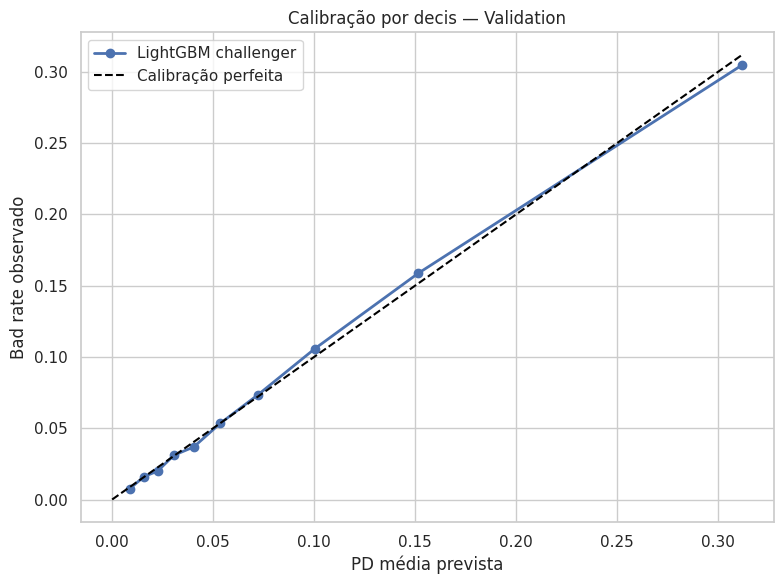

In [37]:
# Visualização da calibração na validation
figure, axis = plt.subplots(
    figsize=(8, 6)
)

axis.plot(
    challenger_validation_calibration[
        "mean_predicted_pd"
    ],
    challenger_validation_calibration[
        "observed_bad_rate"
    ],
    marker="o",
    linewidth=2,
    label="LightGBM challenger",
)

calibration_limit = max(
    challenger_validation_calibration[
        "mean_predicted_pd"
    ].max(),
    challenger_validation_calibration[
        "observed_bad_rate"
    ].max(),
)

axis.plot(
    [
        0,
        calibration_limit,
    ],
    [
        0,
        calibration_limit,
    ],
    linestyle="--",
    color="black",
    label="Calibração perfeita",
)

axis.set_title(
    "Calibração por decis — Validation"
)

axis.set_xlabel(
    "PD média prevista"
)

axis.set_ylabel(
    "Bad rate observado"
)

axis.legend()

plt.tight_layout()

CHALLENGER_VALIDATION_CALIBRATION_FIGURE_PATH = (
    paths.figures
    / "lightgbm_validation_calibration.png"
)

plt.savefig(
    CHALLENGER_VALIDATION_CALIBRATION_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Interpretabilidade do Challenger

### 1. Feature importance por ganho

A importância por ganho mede quanto os splits associados a cada feature contribuíram para a redução da função de perda ao longo das árvores.

Essa medida ajuda a identificar as features mais utilizadas pelo modelo, mas apresenta limitações:

- não mostra a direção do efeito;
- não representa causalidade;
- pode distribuir importância entre features correlacionadas;
- não explica uma previsão individual.

Por isso, ela será complementada por SHAP.

In [38]:
# Construção da feature importance por ganho
challenger_feature_importance = (
    pd.DataFrame(
        {
            "feature": (
                challenger_model
                .booster_
                .feature_name()
            ),
            "gain_importance": (
                challenger_model
                .booster_
                .feature_importance(
                    importance_type="gain"
                )
            ),
            "split_importance": (
                challenger_model
                .booster_
                .feature_importance(
                    importance_type="split"
                )
            ),
        }
    )
)

challenger_feature_importance[
    "gain_share"
] = (
    challenger_feature_importance[
        "gain_importance"
    ]
    / challenger_feature_importance[
        "gain_importance"
    ].sum()
)

challenger_feature_importance = (
    challenger_feature_importance
    .sort_values(
        "gain_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    challenger_feature_importance.head(30)
)

,feature,gain_importance,split_importance,gain_share
0,EXT_SOURCE_MEAN,"57,725.9998",151,0.2344
1,ORGANIZATION_TYPE,"22,648.3895",1385,0.0920
2,EXT_SOURCE_MIN,"13,144.0699",92,0.0534
3,EXT_SOURCE_MAX,"9,949.4989",72,0.0404
4,BU_DEBT_CREDIT_RATIO_MAX,"6,638.5176",82,0.0270
5,CREDIT_ANNUITY_RATIO,"6,296.4179",236,0.0256
6,CC_RECENT_UTILIZATION_MAX,"5,573.3013",58,0.0226
7,CREDIT_GOODS_RATIO,"4,726.0138",73,0.0192
8,EXT_SOURCE_3,"3,808.1482",117,0.0155
9,EMPLOYMENT_YEARS,"3,621.8117",82,0.0147


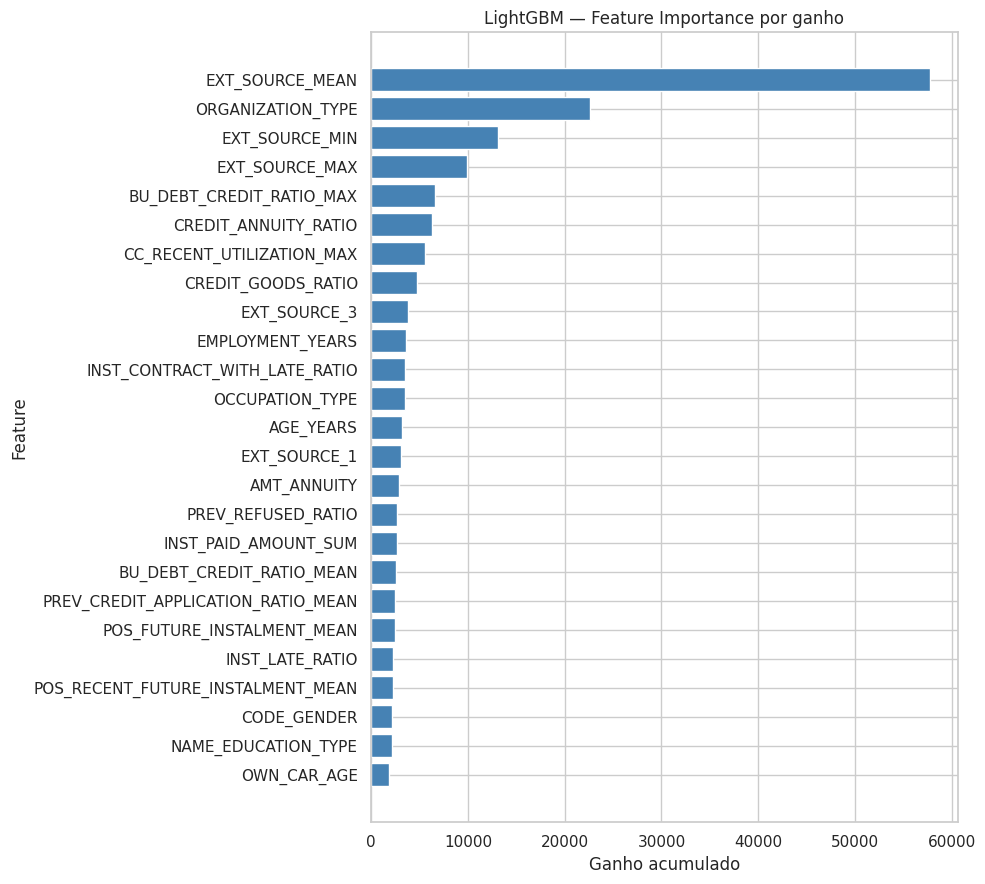

In [39]:
# Visualização da feature importance por ganho
top_gain_features = (
    challenger_feature_importance
    .head(25)
    .sort_values(
        "gain_importance",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(10, 9)
)

axis.barh(
    top_gain_features["feature"],
    top_gain_features[
        "gain_importance"
    ],
    color="steelblue",
)

axis.set_title(
    "LightGBM — Feature Importance por ganho"
)

axis.set_xlabel(
    "Ganho acumulado"
)

axis.set_ylabel(
    "Feature"
)

plt.tight_layout()

GAIN_IMPORTANCE_FIGURE_PATH = (
    paths.figures
    / "lightgbm_gain_importance.png"
)

plt.savefig(
    GAIN_IMPORTANCE_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 2. Interpretação por SHAP

SHAP atribui a cada feature uma contribuição para a previsão de cada observação.

Para modelos de árvore, os SHAP values representam como cada feature desloca a previsão em relação ao valor base do modelo.

No resumo global:

- maior valor absoluto médio de SHAP indica maior influência;
- valores SHAP positivos deslocam a previsão para maior risco;
- valores SHAP negativos deslocam a previsão para menor risco.

A análise será realizada sobre uma amostra da validation para controlar o custo computacional. Essa amostra será utilizada apenas para interpretação, não para treinamento ou seleção do modelo.

In [40]:
# Construção da amostra para SHAP
SHAP_SAMPLE_SIZE = 5_000

shap_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_validation_lgbm),
)

X_shap_sample = (
    X_validation_lgbm
    .sample(
        n=shap_sample_size,
        random_state=RANDOM_STATE,
    )
    .copy()
)

print(
    "Observações na amostra SHAP: "
    f"{len(X_shap_sample):,}"
)

Observações na amostra SHAP: 5,000


In [41]:
# Cálculo dos SHAP values
shap_start_time = time.perf_counter()

shap_explainer = shap.TreeExplainer(
    challenger_model
)

shap_explanation = shap_explainer(
    X_shap_sample
)

shap_values_array = np.asarray(
    shap_explanation.values
)

if shap_values_array.ndim == 3:
    shap_values_array = (
        shap_values_array[:, :, 1]
    )

shap_elapsed_time = (
    time.perf_counter()
    - shap_start_time
)

print(
    "SHAP concluído em "
    f"{shap_elapsed_time:.2f} segundos."
)

print(
    "Dimensão dos SHAP values: "
    f"{shap_values_array.shape}"
)

SHAP concluído em 6.37 segundos.
Dimensão dos SHAP values: (5000, 325)


In [42]:
# Construção da importância global por SHAP
shap_importance_table = pd.DataFrame(
    {
        "feature": (
            X_shap_sample.columns
        ),
        "mean_absolute_shap": (
            np.abs(
                shap_values_array
            ).mean(axis=0)
        ),
    }
)

shap_importance_table[
    "shap_share"
] = (
    shap_importance_table[
        "mean_absolute_shap"
    ]
    / shap_importance_table[
        "mean_absolute_shap"
    ].sum()
)

shap_importance_table = (
    shap_importance_table
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    shap_importance_table.head(30)
)

,feature,mean_absolute_shap,shap_share
0,EXT_SOURCE_MEAN,0.3337,0.0771
1,AMT_ANNUITY,0.1160,0.0268
2,CODE_GENDER,0.1138,0.0263
3,BU_DEBT_CREDIT_RATIO_MAX,0.1133,0.0262
4,ORGANIZATION_TYPE,0.1022,0.0236
5,CREDIT_ANNUITY_RATIO,0.1000,0.0231
6,CREDIT_GOODS_RATIO,0.0941,0.0218
7,OWN_CAR_AGE,0.0812,0.0188
8,EMPLOYMENT_YEARS,0.0777,0.0180
9,POS_RECENT_FUTURE_INSTALMENT_MEAN,0.0770,0.0178


In [43]:
# Preparação dos dados para visualização SHAP
X_shap_plot = X_shap_sample.copy()

for column in categorical_features:
    X_shap_plot[column] = (
        X_shap_plot[column]
        .cat.codes
        .replace(
            -1,
            np.nan,
        )
        .astype("float32")
    )

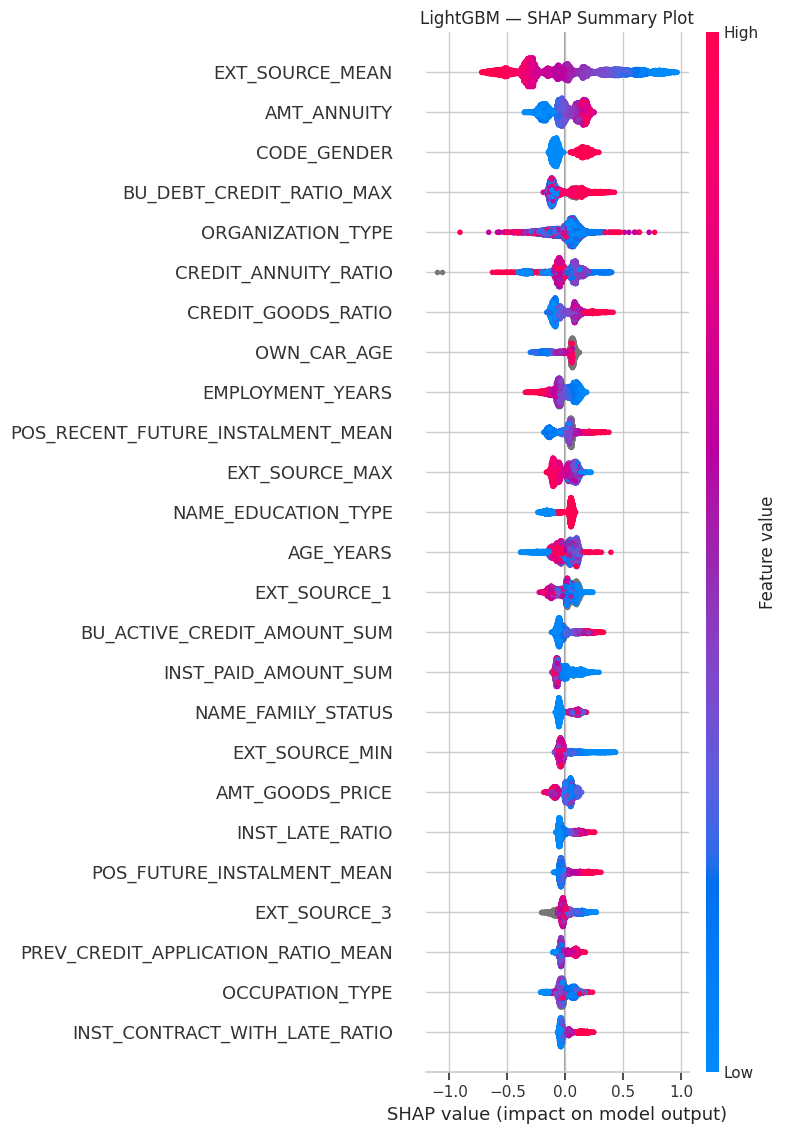

In [44]:
# Visualização global dos SHAP values
shap.summary_plot(
    shap_values_array,
    X_shap_plot,
    feature_names=(
        X_shap_plot.columns
    ),
    max_display=25,
    show=False,
)

plt.title(
    "LightGBM — SHAP Summary Plot"
)

plt.tight_layout()

SHAP_SUMMARY_FIGURE_PATH = (
    paths.figures
    / "lightgbm_shap_summary.png"
)

plt.savefig(
    SHAP_SUMMARY_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 3. Comparação entre ganho e SHAP

Feature importance por ganho e SHAP medem aspectos diferentes:

- **gain importance:** redução acumulada da função de perda nos splits;
- **mean absolute SHAP:** magnitude média da contribuição da feature para as previsões.

A comparação ajuda a identificar features que são estruturalmente importantes para as árvores e que também exercem influência relevante nas previsões individuais.

Diferenças de posição entre os rankings são esperadas e não representam necessariamente inconsistência.

In [45]:
# Consolidação das medidas de importância
importance_comparison_table = (
    challenger_feature_importance[
        [
            "feature",
            "gain_importance",
            "gain_share",
            "split_importance",
        ]
    ]
    .merge(
        shap_importance_table[
            [
                "feature",
                "mean_absolute_shap",
                "shap_share",
            ]
        ],
        on="feature",
        how="left",
        validate="one_to_one",
    )
)

importance_comparison_table[
    "gain_rank"
] = (
    importance_comparison_table[
        "gain_importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

importance_comparison_table[
    "shap_rank"
] = (
    importance_comparison_table[
        "mean_absolute_shap"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

importance_comparison_table[
    "average_rank"
] = (
    importance_comparison_table[
        [
            "gain_rank",
            "shap_rank",
        ]
    ]
    .mean(axis=1)
)

importance_comparison_table = (
    importance_comparison_table
    .sort_values(
        "average_rank",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    importance_comparison_table.head(30)
)

,feature,gain_importance,gain_share,split_importance,mean_absolute_shap,shap_share,gain_rank,shap_rank,average_rank
0,EXT_SOURCE_MEAN,"57,725.9998",0.2344,151,0.3337,0.0771,1,1,1.0000
1,ORGANIZATION_TYPE,"22,648.3895",0.0920,1385,0.1022,0.0236,2,5,3.5000
2,BU_DEBT_CREDIT_RATIO_MAX,"6,638.5176",0.0270,82,0.1133,0.0262,5,4,4.5000
3,CREDIT_ANNUITY_RATIO,"6,296.4179",0.0256,236,0.1000,0.0231,6,6,6.0000
4,CREDIT_GOODS_RATIO,"4,726.0138",0.0192,73,0.0941,0.0218,8,7,7.5000
5,EXT_SOURCE_MAX,"9,949.4989",0.0404,72,0.0765,0.0177,4,11,7.5000
6,AMT_ANNUITY,"2,849.9841",0.0116,113,0.1160,0.0268,15,2,8.5000
7,EMPLOYMENT_YEARS,"3,621.8117",0.0147,82,0.0777,0.0180,10,9,9.5000
8,EXT_SOURCE_MIN,"13,144.0699",0.0534,92,0.0612,0.0141,3,18,10.5000
9,CODE_GENDER,"2,126.3669",0.0086,47,0.1138,0.0263,23,3,13.0000


In [46]:
# Resumo da utilização das features pelo LightGBM
used_feature_count = int(
    (
        challenger_feature_importance[
            "split_importance"
        ]
        > 0
    ).sum()
)

unused_feature_count = int(
    (
        challenger_feature_importance[
            "split_importance"
        ]
        == 0
    ).sum()
)

feature_usage_summary = pd.DataFrame(
    [
        {
            "status": "Utilizada em splits",
            "quantity": used_feature_count,
        },
        {
            "status": "Não utilizada",
            "quantity": unused_feature_count,
        },
    ]
)

display(feature_usage_summary)

,status,quantity
0,Utilizada em splits,278
1,Não utilizada,47


In [47]:
# Cálculo da concentração das importâncias
importance_concentration = pd.DataFrame(
    [
        {
            "top_features": 5,
            "gain_share": (
                challenger_feature_importance
                .head(5)["gain_share"]
                .sum()
            ),
            "shap_share": (
                shap_importance_table
                .head(5)["shap_share"]
                .sum()
            ),
        },
        {
            "top_features": 10,
            "gain_share": (
                challenger_feature_importance
                .head(10)["gain_share"]
                .sum()
            ),
            "shap_share": (
                shap_importance_table
                .head(10)["shap_share"]
                .sum()
            ),
        },
        {
            "top_features": 20,
            "gain_share": (
                challenger_feature_importance
                .head(20)["gain_share"]
                .sum()
            ),
            "shap_share": (
                shap_importance_table
                .head(20)["shap_share"]
                .sum()
            ),
        },
    ]
)

display(importance_concentration)

,top_features,gain_share,shap_share
0,5,0.4472,0.1800
1,10,0.5447,0.2794
2,20,0.6625,0.4356


## Avaliação Final no Holdout Test

### 1. Preparação do holdout

Todas as decisões de modelagem foram concluídas utilizando train e validation:

- universo de features;
- tratamento das categóricas;
- configuração das árvores;
- regularização;
- early stopping;
- seleção entre os modelos candidatos.

O holdout test será agora preparado com as categorias definidas no train e avaliado sem qualquer reajuste adicional.

In [48]:
# Preparação das features do holdout
X_holdout_test_lgbm = (
    holdout_test_df[
        challenger_features
    ]
    .copy()
)

y_holdout_test = (
    holdout_test_df[
        TARGET_COLUMN
    ]
    .astype("int8")
    .copy()
)

unknown_holdout_records = []

for column in categorical_features:
    train_categories = (
        categorical_levels[column]
    )

    unknown_holdout_mask = (
        X_holdout_test_lgbm[column]
        .notna()
        & ~X_holdout_test_lgbm[
            column
        ].isin(train_categories)
    )

    unknown_holdout_records.append(
        {
            "feature": column,
            "unknown_holdout_count": int(
                unknown_holdout_mask.sum()
            ),
        }
    )

    categorical_dtype = (
        pd.CategoricalDtype(
            categories=train_categories
        )
    )

    X_holdout_test_lgbm[column] = (
        X_holdout_test_lgbm[column]
        .astype(categorical_dtype)
    )

for column in numerical_features:
    X_holdout_test_lgbm[column] = (
        X_holdout_test_lgbm[column]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

unknown_holdout_summary = pd.DataFrame(
    unknown_holdout_records
)

print(
    f"X_holdout_test_lgbm: "
    f"{X_holdout_test_lgbm.shape}"
)

print(
    "Categóricas com categorias desconhecidas: "
    f"{int((unknown_holdout_summary['unknown_holdout_count'] > 0).sum())}"
)

X_holdout_test_lgbm: (46127, 325)
Categóricas com categorias desconhecidas: 0


In [49]:
# Cálculo das probabilidades no holdout
challenger_holdout_pd = (
    challenger_model.predict_proba(
        X_holdout_test_lgbm,
        num_iteration=(
            challenger_model
            .best_iteration_
        ),
    )[:, 1]
)

print(
    "PD média prevista no holdout: "
    f"{challenger_holdout_pd.mean():.4%}"
)

print(
    "Bad rate observado no holdout: "
    f"{y_holdout_test.mean():.4%}"
)

PD média prevista no holdout: 8.0443%
Bad rate observado no holdout: 8.0734%


In [50]:
# Comparação do desempenho entre as amostras
challenger_final_evaluation_records = []

for (
    sample_name,
    target,
    predicted_probability,
) in [
    (
        "train",
        y_train,
        challenger_train_pd,
    ),
    (
        "validation",
        y_validation,
        challenger_validation_pd,
    ),
    (
        "holdout_test",
        y_holdout_test,
        challenger_holdout_pd,
    ),
]:
    metrics = calculate_binary_metrics(
        target,
        predicted_probability,
    )

    challenger_final_evaluation_records.append(
        {
            "sample": sample_name,
            **metrics,
        }
    )

challenger_final_evaluation = pd.DataFrame(
    challenger_final_evaluation_records
)

display(
    challenger_final_evaluation
)

,sample,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,train,0.8370,0.6741,0.5178,0.3770,0.0613,0.2181,0.0808,0.0807
1,validation,0.7912,0.5824,0.4423,0.2876,0.0656,0.2356,0.0807,0.0807
2,holdout_test,0.7946,0.5892,0.4484,0.2895,0.0654,0.2346,0.0804,0.0807


In [51]:
# Construção da calibração no holdout
challenger_holdout_calibration = (
    build_calibration_table(
        y_true=y_holdout_test,
        predicted_probability=(
            challenger_holdout_pd
        ),
        number_of_bins=10,
    )
)

display(
    challenger_holdout_calibration
)

,risk_decile,clients,events,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,portfolio_share,calibration_difference
0,1,4613,44,0.0011,0.0124,0.0085,0.0095,0.1000,-0.0010
1,2,4613,69,0.0124,0.0188,0.0156,0.0150,0.1000,0.0006
2,3,4612,91,0.0188,0.0261,0.0223,0.0197,0.1000,0.0026
3,4,4613,137,0.0261,0.0346,0.0302,0.0297,0.1000,0.0005
4,5,4613,173,0.0346,0.0455,0.0398,0.0375,0.1000,0.0023
5,6,4612,255,0.0455,0.0605,0.0526,0.0553,0.1000,-0.0027
6,7,4613,311,0.0605,0.0828,0.0708,0.0674,0.1000,0.0034
7,8,4612,434,0.0828,0.1187,0.0991,0.0941,0.1000,0.0050
8,9,4613,765,0.1187,0.1939,0.1514,0.1658,0.1000,-0.0145
9,10,4613,1445,0.1939,0.8780,0.3141,0.3132,0.1000,0.0008


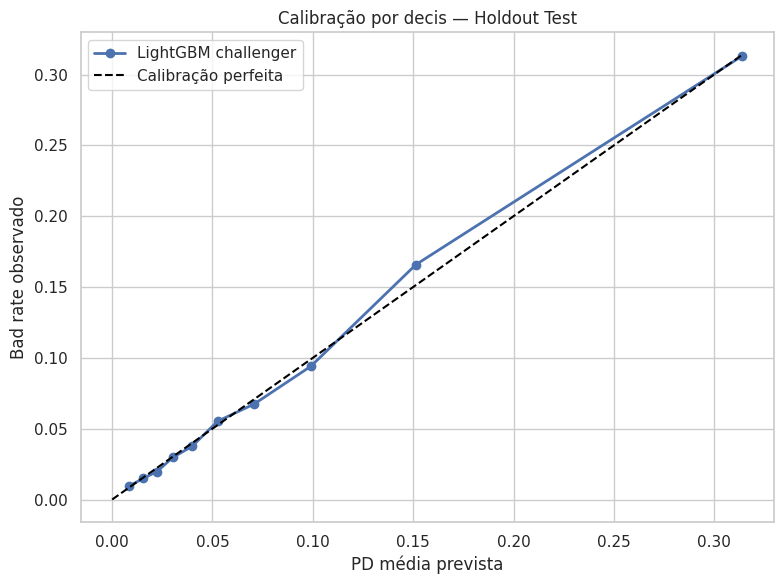

In [52]:
# Visualização da calibração no holdout
figure, axis = plt.subplots(
    figsize=(8, 6)
)

axis.plot(
    challenger_holdout_calibration[
        "mean_predicted_pd"
    ],
    challenger_holdout_calibration[
        "observed_bad_rate"
    ],
    marker="o",
    linewidth=2,
    label="LightGBM challenger",
)

calibration_limit = max(
    challenger_holdout_calibration[
        "mean_predicted_pd"
    ].max(),
    challenger_holdout_calibration[
        "observed_bad_rate"
    ].max(),
)

axis.plot(
    [0, calibration_limit],
    [0, calibration_limit],
    linestyle="--",
    color="black",
    label="Calibração perfeita",
)

axis.set_title(
    "Calibração por decis — Holdout Test"
)

axis.set_xlabel(
    "PD média prevista"
)

axis.set_ylabel(
    "Bad rate observado"
)

axis.legend()

plt.tight_layout()

CHALLENGER_HOLDOUT_CALIBRATION_FIGURE_PATH = (
    paths.figures
    / "lightgbm_holdout_calibration.png"
)

plt.savefig(
    CHALLENGER_HOLDOUT_CALIBRATION_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 2. Incerteza das métricas no holdout

As métricas do holdout serão acompanhadas por intervalos de confiança de 95% obtidos por bootstrap.

Esses intervalos representam a incerteza amostral das estimativas e serão utilizados posteriormente na comparação entre o challenger e a Logistic Regression.

In [53]:
# Estimação dos intervalos de confiança por bootstrap
BOOTSTRAP_ITERATIONS = 500
CONFIDENCE_LEVEL = 0.95

random_generator = np.random.default_rng(
    RANDOM_STATE
)

holdout_target_array = np.asarray(
    y_holdout_test
)

holdout_probability_array = np.asarray(
    challenger_holdout_pd
)

number_of_holdout_records = len(
    holdout_target_array
)

bootstrap_records = []

for bootstrap_iteration in range(
    BOOTSTRAP_ITERATIONS
):
    bootstrap_indices = (
        random_generator.integers(
            low=0,
            high=number_of_holdout_records,
            size=number_of_holdout_records,
        )
    )

    bootstrap_target = (
        holdout_target_array[
            bootstrap_indices
        ]
    )

    bootstrap_probability = (
        holdout_probability_array[
            bootstrap_indices
        ]
    )

    bootstrap_metrics = (
        calculate_binary_metrics(
            bootstrap_target,
            bootstrap_probability,
        )
    )

    bootstrap_records.append(
        {
            "roc_auc": (
                bootstrap_metrics[
                    "roc_auc"
                ]
            ),
            "gini": (
                bootstrap_metrics[
                    "gini"
                ]
            ),
            "ks": (
                bootstrap_metrics["ks"]
            ),
            "brier_score": (
                bootstrap_metrics[
                    "brier_score"
                ]
            ),
            "log_loss": (
                bootstrap_metrics[
                    "log_loss"
                ]
            ),
        }
    )

challenger_bootstrap_metrics = pd.DataFrame(
    bootstrap_records
)

print(
    "Iterações concluídas: "
    f"{len(challenger_bootstrap_metrics):,}"
)

Iterações concluídas: 500


In [54]:
# Construção dos intervalos de confiança
alpha = 1 - CONFIDENCE_LEVEL

challenger_holdout_point_metrics = (
    calculate_binary_metrics(
        y_holdout_test,
        challenger_holdout_pd,
    )
)

confidence_interval_records = []

for metric_name in [
    "roc_auc",
    "gini",
    "ks",
    "brier_score",
    "log_loss",
]:
    confidence_interval_records.append(
        {
            "metric": metric_name,
            "point_estimate": (
                challenger_holdout_point_metrics[
                    metric_name
                ]
            ),
            "bootstrap_mean": (
                challenger_bootstrap_metrics[
                    metric_name
                ].mean()
            ),
            "ci_lower_95": (
                challenger_bootstrap_metrics[
                    metric_name
                ].quantile(
                    alpha / 2
                )
            ),
            "ci_upper_95": (
                challenger_bootstrap_metrics[
                    metric_name
                ].quantile(
                    1 - alpha / 2
                )
            ),
        }
    )

challenger_confidence_intervals = (
    pd.DataFrame(
        confidence_interval_records
    )
)

display(
    challenger_confidence_intervals
)

,metric,point_estimate,bootstrap_mean,ci_lower_95,ci_upper_95
0,roc_auc,0.7946,0.7946,0.7874,0.8023
1,gini,0.5892,0.5892,0.5748,0.6046
2,ks,0.4484,0.4501,0.4346,0.4648
3,brier_score,0.0654,0.0654,0.0636,0.0673
4,log_loss,0.2346,0.2346,0.2292,0.2404


## Visualizações Finais

As curvas finais permitem comparar o comportamento do challenger entre train, validation e holdout test e visualizar o ponto de máxima separação entre eventos e não eventos.

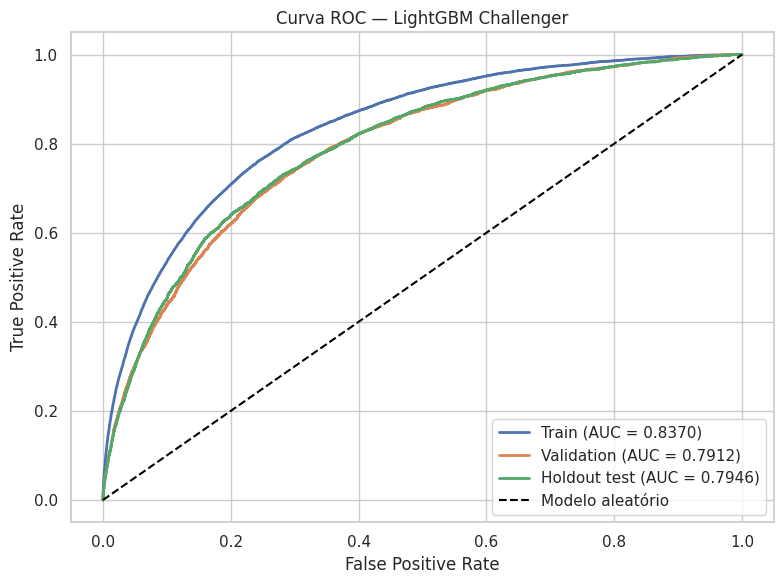

In [55]:
# Visualização das curvas ROC
figure, axis = plt.subplots(
    figsize=(8, 6)
)

roc_samples = [
    (
        "Train",
        y_train,
        challenger_train_pd,
    ),
    (
        "Validation",
        y_validation,
        challenger_validation_pd,
    ),
    (
        "Holdout test",
        y_holdout_test,
        challenger_holdout_pd,
    ),
]

for (
    sample_name,
    target,
    probability,
) in roc_samples:
    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            target,
            probability,
        )
    )

    auc_value = roc_auc_score(
        target,
        probability,
    )

    axis.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{sample_name} "
            f"(AUC = {auc_value:.4f})"
        ),
    )

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Modelo aleatório",
)

axis.set_title(
    "Curva ROC — LightGBM Challenger"
)

axis.set_xlabel(
    "False Positive Rate"
)

axis.set_ylabel(
    "True Positive Rate"
)

axis.legend()

plt.tight_layout()

CHALLENGER_ROC_FIGURE_PATH = (
    paths.figures
    / "lightgbm_roc_curve.png"
)

plt.savefig(
    CHALLENGER_ROC_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

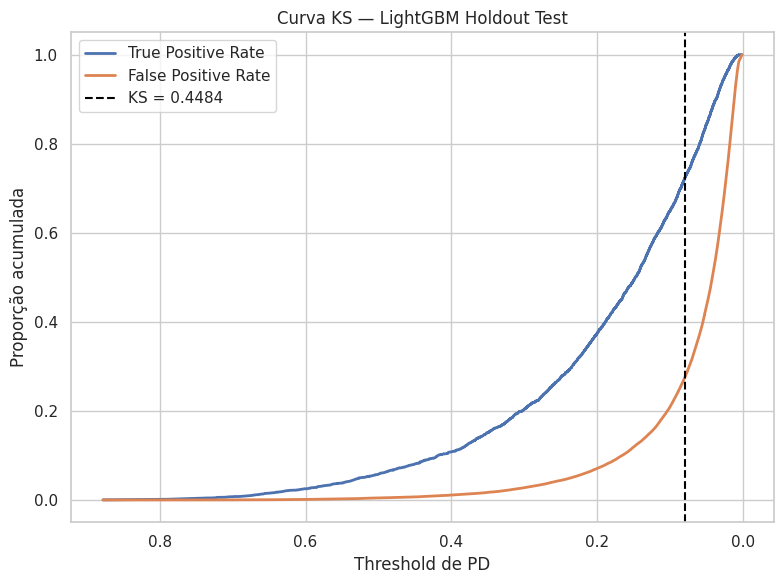

In [56]:
# Visualização do KS no holdout
holdout_fpr, holdout_tpr, holdout_thresholds = (
    roc_curve(
        y_holdout_test,
        challenger_holdout_pd,
    )
)

holdout_ks_values = (
    holdout_tpr
    - holdout_fpr
)

holdout_ks_index = int(
    np.argmax(
        holdout_ks_values
    )
)

holdout_ks_value = (
    holdout_ks_values[
        holdout_ks_index
    ]
)

holdout_ks_threshold = (
    holdout_thresholds[
        holdout_ks_index
    ]
)

finite_threshold_mask = np.isfinite(
    holdout_thresholds
)

figure, axis = plt.subplots(
    figsize=(8, 6)
)

axis.plot(
    holdout_thresholds[
        finite_threshold_mask
    ],
    holdout_tpr[
        finite_threshold_mask
    ],
    linewidth=2,
    label="True Positive Rate",
)

axis.plot(
    holdout_thresholds[
        finite_threshold_mask
    ],
    holdout_fpr[
        finite_threshold_mask
    ],
    linewidth=2,
    label="False Positive Rate",
)

axis.axvline(
    holdout_ks_threshold,
    color="black",
    linestyle="--",
    label=(
        f"KS = {holdout_ks_value:.4f}"
    ),
)

axis.set_title(
    "Curva KS — LightGBM Holdout Test"
)

axis.set_xlabel(
    "Threshold de PD"
)

axis.set_ylabel(
    "Proporção acumulada"
)

axis.invert_xaxis()
axis.legend()

plt.tight_layout()

CHALLENGER_KS_FIGURE_PATH = (
    paths.figures
    / "lightgbm_ks_curve.png"
)

plt.savefig(
    CHALLENGER_KS_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [57]:
# Validação das figuras do challenger
challenger_figure_paths = {
    "validation_calibration": (
        CHALLENGER_VALIDATION_CALIBRATION_FIGURE_PATH
    ),
    "holdout_calibration": (
        CHALLENGER_HOLDOUT_CALIBRATION_FIGURE_PATH
    ),
    "gain_importance": (
        GAIN_IMPORTANCE_FIGURE_PATH
    ),
    "shap_summary": (
        SHAP_SUMMARY_FIGURE_PATH
    ),
    "roc_curve": (
        CHALLENGER_ROC_FIGURE_PATH
    ),
    "ks_curve": (
        CHALLENGER_KS_FIGURE_PATH
    ),
}

challenger_figure_inventory = pd.DataFrame(
    [
        {
            "figure": figure_name,
            "path": str(figure_path),
            "exists": (
                figure_path.exists()
            ),
        }
        for figure_name, figure_path
        in challenger_figure_paths.items()
    ]
)

display(
    challenger_figure_inventory
)

,figure,path,exists
0,validation_calibration,/content/home-credit-default-risk/reports/figu...,True
1,holdout_calibration,/content/home-credit-default-risk/reports/figu...,True
2,gain_importance,/content/home-credit-default-risk/reports/figu...,True
3,shap_summary,/content/home-credit-default-risk/reports/figu...,True
4,roc_curve,/content/home-credit-default-risk/reports/figu...,True
5,ks_curve,/content/home-credit-default-risk/reports/figu...,True


## Persistência dos Artefatos

Os artefatos necessários para reproduzir as previsões do challenger serão persistidos:

- modelo LightGBM em formato Joblib;
- modelo no formato nativo do LightGBM;
- lista ordenada de features;
- níveis das variáveis categóricas;
- configuração e melhor iteração;
- previsões das três amostras;
- métricas e intervalos de confiança;
- tabelas de calibração;
- resultados do tuning;
- feature importance e SHAP.

In [58]:
# Construção da configuração final do challenger
selected_challenger_parameters = (
    baseline_parameters.copy()
)

selected_challenger_parameters.update(
    challenger_configurations[
        SELECTED_CONFIGURATION
    ]
)

challenger_model_config = {
    "model_type": "LGBMClassifier",
    "configuration_name": (
        SELECTED_CONFIGURATION
    ),
    "target": TARGET_COLUMN,
    "identifier": ID_COLUMN,
    "random_state": RANDOM_STATE,
    "number_of_features": len(
        challenger_features
    ),
    "number_of_categorical_features": len(
        categorical_features
    ),
    "best_iteration": int(
        challenger_model.best_iteration_
    ),
    "parameters": (
        selected_challenger_parameters
    ),
    "fairness_attention_features": [
        "CODE_GENDER",
    ],
}

In [59]:
# Preparação dos níveis categóricos
serializable_categorical_levels = {
    column: [
        (
            value.item()
            if isinstance(
                value,
                np.generic,
            )
            else value
        )
        for value in values
    ]
    for column, values
    in categorical_levels.items()
}

In [60]:
# Construção das previsões do challenger
challenger_predictions = pd.concat(
    [
        pd.DataFrame(
            {
                ID_COLUMN: train_df[
                    ID_COLUMN
                ].to_numpy(),
                TARGET_COLUMN: (
                    y_train.to_numpy()
                ),
                "sample": "train",
                "predicted_pd": (
                    challenger_train_pd
                ),
            }
        ),
        pd.DataFrame(
            {
                ID_COLUMN: validation_df[
                    ID_COLUMN
                ].to_numpy(),
                TARGET_COLUMN: (
                    y_validation.to_numpy()
                ),
                "sample": "validation",
                "predicted_pd": (
                    challenger_validation_pd
                ),
            }
        ),
        pd.DataFrame(
            {
                ID_COLUMN: holdout_test_df[
                    ID_COLUMN
                ].to_numpy(),
                TARGET_COLUMN: (
                    y_holdout_test.to_numpy()
                ),
                "sample": "holdout_test",
                "predicted_pd": (
                    challenger_holdout_pd
                ),
            }
        ),
    ],
    ignore_index=True,
)

print(
    "Total de previsões: "
    f"{len(challenger_predictions):,}"
)

Total de previsões: 307,511


In [61]:
# Identificação das features não utilizadas
unused_challenger_features = (
    challenger_feature_importance.loc[
        challenger_feature_importance[
            "split_importance"
        ]
        == 0,
        [
            "feature",
            "gain_importance",
            "split_importance",
        ],
    ]
    .reset_index(drop=True)
)

display(
    unused_challenger_features
)

,feature,gain_importance,split_importance
0,BU_CURRENCY_COUNT,0.0000,0
1,BU_OVERDUE_CREDIT_RATIO_MAX,0.0000,0
2,BU_BB_SEVERE_DPD_COUNT_SUM,0.0000,0
3,POS_CONTRACT_WITH_DPD_COUNT,0.0000,0
4,FLAG_EMP_PHONE,0.0000,0
5,POS_CONTRACT_WITH_SEVERE_DPD_COUNT,0.0000,0
6,POS_SEVERE_DPD_MONTH_RATIO,0.0000,0
7,FLAG_MOBIL,0.0000,0
8,BU_BB_SEVERE_DPD_RATIO_MAX,0.0000,0
9,DAYS_EMPLOYED_SPECIAL,0.0000,0


In [62]:
# Definição dos caminhos dos artefatos
CHALLENGER_MODEL_PATH = (
    paths.models
    / "lightgbm_challenger.joblib"
)

CHALLENGER_NATIVE_MODEL_PATH = (
    paths.models
    / "lightgbm_challenger.txt"
)

CHALLENGER_FEATURES_PATH = (
    paths.metadata
    / "lightgbm_challenger_features.json"
)

CHALLENGER_CATEGORIES_PATH = (
    paths.metadata
    / "lightgbm_categorical_levels.json"
)

CHALLENGER_CONFIG_PATH = (
    paths.metadata
    / "lightgbm_challenger_config.json"
)

CHALLENGER_PREDICTIONS_PATH = (
    paths.data_processed
    / "lightgbm_challenger_predictions.parquet"
)

CHALLENGER_METRICS_PATH = (
    paths.tables
    / "lightgbm_challenger_metrics.csv"
)

CHALLENGER_CONFIDENCE_PATH = (
    paths.tables
    / "lightgbm_challenger_confidence_intervals.csv"
)

CHALLENGER_VALIDATION_CALIBRATION_PATH = (
    paths.tables
    / "lightgbm_validation_calibration.csv"
)

CHALLENGER_HOLDOUT_CALIBRATION_PATH = (
    paths.tables
    / "lightgbm_holdout_calibration.csv"
)

CHALLENGER_TUNING_PATH = (
    paths.tables
    / "lightgbm_tuning_results.csv"
)

CHALLENGER_GAIN_IMPORTANCE_PATH = (
    paths.tables
    / "lightgbm_gain_importance.csv"
)

CHALLENGER_SHAP_IMPORTANCE_PATH = (
    paths.tables
    / "lightgbm_shap_importance.csv"
)

CHALLENGER_IMPORTANCE_COMPARISON_PATH = (
    paths.tables
    / "lightgbm_importance_comparison.csv"
)

CHALLENGER_UNUSED_FEATURES_PATH = (
    paths.metadata
    / "lightgbm_unused_features.csv"
)

In [63]:
# Persistência dos artefatos do challenger
joblib.dump(
    challenger_model,
    CHALLENGER_MODEL_PATH,
)

challenger_model.booster_.save_model(
    str(
        CHALLENGER_NATIVE_MODEL_PATH
    ),
    num_iteration=(
        challenger_model.best_iteration_
    ),
)

with open(
    CHALLENGER_FEATURES_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        challenger_features,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    CHALLENGER_CATEGORIES_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        serializable_categorical_levels,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    CHALLENGER_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        challenger_model_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

challenger_predictions.to_parquet(
    CHALLENGER_PREDICTIONS_PATH,
    index=False,
)

challenger_final_evaluation.to_csv(
    CHALLENGER_METRICS_PATH,
    index=False,
)

challenger_confidence_intervals.to_csv(
    CHALLENGER_CONFIDENCE_PATH,
    index=False,
)

challenger_validation_calibration.to_csv(
    CHALLENGER_VALIDATION_CALIBRATION_PATH,
    index=False,
)

challenger_holdout_calibration.to_csv(
    CHALLENGER_HOLDOUT_CALIBRATION_PATH,
    index=False,
)

challenger_tuning_table.to_csv(
    CHALLENGER_TUNING_PATH,
    index=False,
)

challenger_feature_importance.to_csv(
    CHALLENGER_GAIN_IMPORTANCE_PATH,
    index=False,
)

shap_importance_table.to_csv(
    CHALLENGER_SHAP_IMPORTANCE_PATH,
    index=False,
)

importance_comparison_table.to_csv(
    CHALLENGER_IMPORTANCE_COMPARISON_PATH,
    index=False,
)

unused_challenger_features.to_csv(
    CHALLENGER_UNUSED_FEATURES_PATH,
    index=False,
)

print(
    "Artefatos do challenger "
    "persistidos com sucesso."
)

Artefatos do challenger persistidos com sucesso.


In [64]:
# Validação dos artefatos persistidos
challenger_artifact_paths = {
    "model_joblib": (
        CHALLENGER_MODEL_PATH
    ),
    "model_native": (
        CHALLENGER_NATIVE_MODEL_PATH
    ),
    "features": (
        CHALLENGER_FEATURES_PATH
    ),
    "categorical_levels": (
        CHALLENGER_CATEGORIES_PATH
    ),
    "config": (
        CHALLENGER_CONFIG_PATH
    ),
    "predictions": (
        CHALLENGER_PREDICTIONS_PATH
    ),
    "metrics": (
        CHALLENGER_METRICS_PATH
    ),
    "confidence_intervals": (
        CHALLENGER_CONFIDENCE_PATH
    ),
    "validation_calibration": (
        CHALLENGER_VALIDATION_CALIBRATION_PATH
    ),
    "holdout_calibration": (
        CHALLENGER_HOLDOUT_CALIBRATION_PATH
    ),
    "tuning": (
        CHALLENGER_TUNING_PATH
    ),
    "gain_importance": (
        CHALLENGER_GAIN_IMPORTANCE_PATH
    ),
    "shap_importance": (
        CHALLENGER_SHAP_IMPORTANCE_PATH
    ),
    "importance_comparison": (
        CHALLENGER_IMPORTANCE_COMPARISON_PATH
    ),
    "unused_features": (
        CHALLENGER_UNUSED_FEATURES_PATH
    ),
}

challenger_artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "path": str(artifact_path),
            "exists": (
                artifact_path.exists()
            ),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else np.nan
            ),
        }
        for artifact_name, artifact_path
        in challenger_artifact_paths.items()
    ]
)

display(
    challenger_artifact_inventory
)

,artifact,path,exists,size_bytes
0,model_joblib,/content/drive/MyDrive/home-credit-default-ris...,True,1458534
1,model_native,/content/drive/MyDrive/home-credit-default-ris...,True,1394628
2,features,/content/drive/MyDrive/home-credit-default-ris...,True,8444
3,categorical_levels,/content/drive/MyDrive/home-credit-default-ris...,True,3177
4,config,/content/drive/MyDrive/home-credit-default-ris...,True,797
5,predictions,/content/drive/MyDrive/home-credit-default-ris...,True,4533249
6,metrics,/content/home-credit-default-risk/reports/tabl...,True,588
7,confidence_intervals,/content/home-credit-default-risk/reports/tabl...,True,483
8,validation_calibration,/content/home-credit-default-risk/reports/tabl...,True,1455
9,holdout_calibration,/content/home-credit-default-risk/reports/tabl...,True,1455


## Conclusão

Este notebook desenvolveu o modelo challenger de Application Score utilizando LightGBM.

O challenger recebeu as 325 features tecnicamente elegíveis da base consolidada:

- 309 features numéricas;
- 16 features categóricas;
- missing values tratados nativamente;
- categóricas processadas pelo suporte nativo do LightGBM.

O modelo baseline apresentou ROC-AUC de 0,7882 na validation, mas também um gap elevado em relação ao train.

Para reduzir o overfitting, foram avaliadas diferentes configurações de:

- quantidade de folhas;
- profundidade máxima;
- quantidade mínima de observações por folha;
- amostragem de linhas;
- amostragem de features;
- regularização L1 e L2;
- ganho mínimo para novos splits.

Os dois melhores candidatos foram comparados por bootstrap pareado. A diferença de ROC-AUC entre `compact_15_strong` e `shallow_7` foi de apenas 0,0004, com intervalo de confiança de 95% entre -0,0009 e 0,0017.

Como o intervalo incluiu zero, não houve evidência suficiente de superioridade do modelo mais complexo. Foi selecionado o `shallow_7`, que apresentou menor gap entre train e validation.

A configuração final utilizou:

- `num_leaves = 7`;
- `max_depth = 3`;
- `min_child_samples = 250`;
- `subsample = 0,80`;
- `colsample_bytree = 0,80`;
- `reg_alpha = 1,00`;
- `reg_lambda = 5,00`;
- `min_split_gain = 0,01`;
- 1.468 árvores definidas por early stopping.

No holdout test, o challenger apresentou:

| Métrica | Resultado | Intervalo de confiança de 95% |
|---|---:|---:|
| ROC-AUC | 0,7946 | [0,7874; 0,8023] |
| Gini | 0,5892 | [0,5748; 0,6046] |
| KS | 0,4484 | [0,4346; 0,4648] |
| PR-AUC | 0,2895 | — |
| Brier Score | 0,0654 | [0,0636; 0,0673] |
| Log Loss | 0,2346 | [0,2292; 0,2404] |

A PD média prevista no holdout foi de aproximadamente 8,04%, enquanto o bad rate observado foi de 8,07%.

A calibração apresentou comportamento monotônico ao longo dos decis. O maior desvio foi observado no 9º decil, com subestimação de aproximadamente 1,45 ponto percentual. A calibração global e o comportamento das demais faixas não indicaram necessidade de recalibração.

A análise de interpretabilidade mostrou que:

- 278 das 325 features foram utilizadas em pelo menos um split;
- 47 features não foram utilizadas;
- `EXT_SOURCE_MEAN` apresentou a maior importância por ganho e por SHAP;
- informações de bureau, histórico de pagamentos, valores financeiros e características da aplicação tiveram contribuição relevante;
- feature importance e SHAP apresentaram rankings complementares.

A presença de `CODE_GENDER` entre as features de maior importância por SHAP exige atenção de fairness e governança.

Uma variável pode apresentar capacidade preditiva e, ainda assim, não ser adequada para utilização em uma decisão de crédito. Portanto, sua presença não deve ser interpretada como recomendação automática de uso em produção.

Entre as principais limitações deste challenger estão:

- ausência de validação temporal Out-of-Time;
- utilização de scores externos cuja metodologia não é disponibilizada;
- diferença ainda relevante entre o desempenho de train e validation, embora reduzida durante o tuning;
- maior complexidade de explicação em comparação à Logistic Regression;
- necessidade de análise de fairness e proxies;
- target entendido como aproximação de default, conforme a definição da Home Credit.

Os artefatos do modelo foram persistidos, incluindo:

- modelo LightGBM;
- configuração selecionada;
- níveis categóricos;
- previsões;
- métricas;
- intervalos de confiança;
- resultados do tuning;
- feature importance;
- importância SHAP;
- tabelas de calibração.

O modelo ainda não será declarado champion apenas por apresentar métricas pontuais superiores à Logistic Regression.

No próximo notebook, os modelos serão comparados de maneira pareada no mesmo holdout, considerando:

- ganho incremental de ROC-AUC, Gini e KS;
- significância e incerteza das diferenças;
- calibração;
- estabilidade;
- interpretabilidade;
- fairness e governança;
- complexidade operacional;
- transformação de PD em score e faixas de risco;
- simulação de cutoffs para Política de Crédito.

A decisão final deverá equilibrar desempenho preditivo, transparência, governança e aplicabilidade ao negócio.